In [33]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

### Import Libraries

Cell ini mengimpor semua library yang dibutuhkan selama proyek berjalan. `cv2` (`OpenCV`) digunakan untuk membaca dan memproses gambar dari direktori dataset, `NumPy` dan `Pandas` untuk manipulasi serta pengelolaan data secara numerik dan tabular, serta `Matplotlib` dan `Seaborn` untuk memvisualisasikan hasil analisis dalam bentuk grafik dan plot.

Untuk bagian machine learning, digunakan tiga model klasifikasi dari `Scikit-learn` yaitu `RandomForestClassifier`, `SVC`, dan `KNeighborsClassifier`. Data dibagi menggunakan `train_test_split` dan dievaluasi dengan `cross_val_predict` untuk hasil yang lebih robust. Performa model diukur menggunakan metrik `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, dan `confusion_matrix`. Fitur tekstur gambar diekstraksi menggunakan `graycomatrix` dan `graycoprops` dari `Scikit-image`, sementara `entropy` dari `Scipy` dipakai untuk mengukur tingkat ketidakpastian distribusi piksel pada gambar.


## Data Loading

In [34]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(
        os.path.join("dataset", sub_folder)
    )

    for filename in sub_folder_files:

        img_path = os.path.join(
            "dataset",
            sub_folder,
            filename
        )

        img = cv.imread(img_path)

        if img is None:
            print(f"Gagal membaca: {img_path}")
            continue

        img = img.astype(np.uint8)

        # grayscale
        img = cv.cvtColor(
            img,
            cv.COLOR_BGR2GRAY
        )

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)

print(f"Jumlah data asli : {len(data)}")

Jumlah data asli : 840


### Load Dataset

Cell ini membaca seluruh gambar dari folder dataset yang dibagi ke dalam beberapa sub-folder, di mana setiap sub-folder mewakili satu kelas label. Setiap gambar dibaca menggunakan `cv.imread()`, lalu dikonversi ke tipe `uint8` untuk memastikan nilai piksel valid (0–255), kemudian diubah ke grayscale menggunakan `cv.COLOR_BGR2GRAY` untuk menyederhanakan data dari 3 channel warna menjadi 1 channel intensitas. Gambar yang gagal dibaca akan dilewati dengan pesan peringatan.

Di akhir cell, `data` dan `labels` dikonversi ke array `NumPy`. `data` menggunakan `dtype=object` karena tiap gambar bisa memiliki ukuran berbeda. Jumlah total data yang berhasil dimuat kemudian dicetak sebagai konfirmasi.


## Visualisasi Sebelum Preprocessing 3

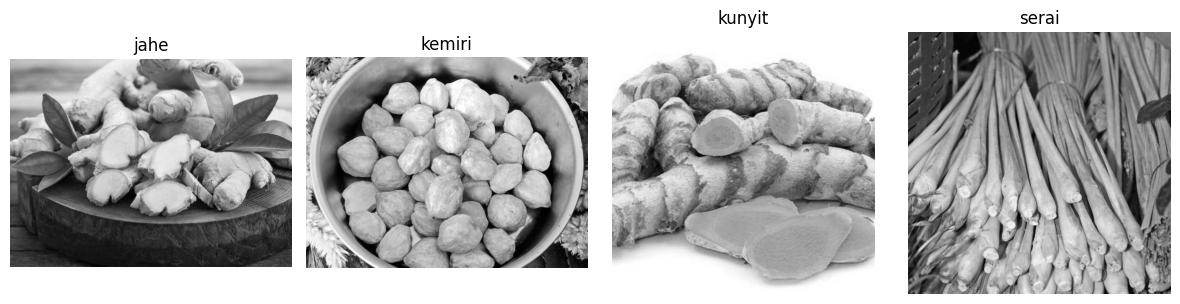

In [35]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    idx = np.where(labels == kelas)[0][0]

    plt.subplot(1, 4, i + 1)
    plt.imshow(data[idx], cmap="gray")
    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualisasi Sebelum Preprocessing 3


Cell ini kembali menampilkan satu sampel gambar dari setiap kelas yang ada di `dataset`. `plt.figure()` dipanggil dengan `figsize=(12, 3)` untuk menentukan ukuran canvas secara keseluruhan. `np.unique()` digunakan untuk mengambil daftar kelas unik dari array `labels`, sehingga setiap kelas hanya direpresentasikan satu kali.

Iterasi dilakukan menggunakan `enumerate()` pada `unique_labels` untuk mendapatkan indeks `i` dan nama kelas `kelas` secara bersamaan. Di dalam iterasi, `np.where()` mencari indeks pertama pada `labels` yang cocok dengan nama kelas saat ini, lalu gambar yang sesuai ditampilkan menggunakan `plt.imshow()` dengan `cmap="gray"` karena gambar sudah dalam format grayscale. Setiap subplot diberi judul nama kelasnya dengan `plt.title()`, dan sumbunya disembunyikan dengan `plt.axis("off")` agar tampilan lebih rapi. Di akhir, `plt.tight_layout()` merapikan jarak antar subplot sebelum `plt.show()` menampilkan keseluruhan figure.

## Data Augmentation

In [36]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):

    img = data[i]
    label = labels[i]
    fname = file_name[i]

    name, ext = os.path.splitext(fname)

    # gambar asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)

    # flip horizontal
    flip_h = cv.flip(img, 1)
    data_augmented.append(flip_h)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipH" + ext
    )

    # flip vertikal
    flip_v = cv.flip(img, 0)
    data_augmented.append(flip_v)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipV" + ext
    )

    # rotasi 90 derajat
    rot_90 = cv.rotate(
        img,
        cv.ROTATE_90_CLOCKWISE
    )
    data_augmented.append(rot_90)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_rot90" + ext
    )

data_augmented = np.array(
    data_augmented,
    dtype=object
)

labels_augmented = np.array(
    labels_augmented
)

print("Data sebelum augmentasi :", len(data))
print("Data setelah augmentasi :", len(data_augmented))

Data sebelum augmentasi : 840
Data setelah augmentasi : 3360


### Data Augmentasi

Cell ini melakukan augmentasi data untuk memperbanyak jumlah sampel training. Setiap gambar asli dari data akan menghasilkan 4 versi gambar: gambar asli, flip horizontal menggunakan `cv.flip(img, 1)`, flip vertikal menggunakan `cv.flip(img, 0)`, dan rotasi 90 derajat searah jarum jam menggunakan `cv.rotate()` dengan parameter `cv.ROTATE_90_CLOCKWISE`. 

Setiap versi augmentasi juga mendapatkan nama file baru dengan sufiks seperti `_flipH`, `_flipV`, dan `_rot90` yang ditambahkan menggunakan `os.path.splitext()` untuk memisahkan nama dan ekstensi file.

Hasil augmentasi disimpan ke dalam tiga list terpisah yaitu `data_augmented`, `labels_augmented`, dan `file_name_augmented`, kemudian dikonversi ke array NumPy menggunakan `np.array()`. `data_augmented` menggunakan `dtype=object` karena gambar bisa memiliki ukuran berbeda. 

Di akhir cell, jumlah data sebelum dan sesudah augmentasi dicetak untuk memverifikasi bahwa jumlah data bertambah 4 kali lipat dari data asli.

## Data Preparation

### Percobaan 2 + Thresholding + Morphological Opening

In [37]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros((new_height, new_width),
                             dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

### Fungsi Resize Gambar

Cell ini mendefinisikan fungsi `resize()` yang digunakan untuk mengubah ukuran gambar menjadi dimensi baru yang ditentukan oleh parameter `new_width` dan `new_height`. Fungsi menerima sebuah gambar grayscale sebagai input, kemudian mengambil ukuran asli gambar melalui `image.shape[:2]` untuk memperoleh nilai tinggi dan lebar awal.

Selanjutnya, dibuat array kosong bernama `resized_image` menggunakan `np.zeros()` dengan ukuran baru yang diinginkan. Array ini akan digunakan untuk menyimpan hasil perubahan ukuran gambar.

Proses resize dilakukan menggunakan dua perulangan `for` yang mengunjungi setiap piksel pada gambar hasil. Untuk setiap posisi piksel baru, koordinat yang bersesuaian pada gambar asli dihitung menggunakan perbandingan skala antara ukuran lama dan ukuran baru. Nilai koordinat tersebut kemudian dibulatkan ke bilangan bulat menggunakan `int()` dan digunakan untuk mengambil nilai piksel dari gambar asli.

Metode yang digunakan pada fungsi ini adalah **Nearest Neighbor Interpolation**, yaitu teknik resize yang menentukan nilai piksel baru berdasarkan piksel terdekat pada gambar asli. Setelah seluruh piksel diproses, fungsi mengembalikan gambar hasil resize melalui `return resized_image`.


In [38]:
def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape, dtype=np.uint8)
    return (
        (image - min_val) /
        (max_val - min_val) * 255
    ).astype(np.uint8)

### Fungsi Normalisasi 

Cell ini mendefinisikan fungsi `normalisasi()` yang digunakan untuk mengubah rentang nilai intensitas piksel gambar ke skala `0–255`. Fungsi diawali dengan mencari nilai minimum dan maksimum piksel menggunakan `np.min()` dan `np.max()`.

Program kemudian memeriksa kondisi `if max_val == min_val` untuk menghindari pembagian dengan nol. Jika seluruh piksel memiliki nilai yang sama, fungsi akan mengembalikan array nol menggunakan `np.zeros()`.

Jika tidak, normalisasi dilakukan menggunakan metode Min-Max Normalization, yaitu dengan menskalakan seluruh nilai piksel ke rentang `0–255`. Hasil normalisasi kemudian dikonversi ke tipe data `uint8` menggunakan `astype(np.uint8)` dan dikembalikan sebagai output fungsi.


In [39]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)

                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter(foto_karim, 3, 'mean')

### Fungsi Filter Citra 

Cell ini mendefinisikan fungsi `filter_citra()` yang mengimplementasikan tiga jenis filter gambar secara manual tanpa library eksternal. Fungsi menerima tiga parameter: `img` sebagai gambar input grayscale, `size` sebagai ukuran kernel filter, dan `mode` sebagai jenis filter yang dipilih. Sebelum filtering dimulai, gambar diberi padding pada tepinya menggunakan `np.pad()` dengan `mode='edge'` agar piksel di tepi gambar tetap bisa diproses. Kanvas output `canvas` dibuat menggunakan `np.zeros_like()` dengan tipe `np.uint8` sebagai tempat menyimpan hasil filter.

Pemilihan mode filter dilakukan menggunakan `match-case`. Pada mode `'mean'`, setiap piksel dihitung dari rata-rata seluruh nilai piksel dalam area kernel `size x size` menggunakan nested loop manual tanpa fungsi bawaan NumPy. Pada mode `'median'`, nilai-nilai piksel dalam kernel dikumpulkan ke list `values`, kemudian diurutkan secara manual menggunakan algoritma bubble sort, lalu diambil nilai tengahnya. Jika jumlah elemen genap, median dihitung dari rata-rata dua nilai tengah. Pada mode `'modus'`, nilai piksel yang paling sering muncul dalam kernel dicari menggunakan dictionary `count` untuk menghitung frekuensi kemunculan setiap nilai, kemudian nilai dengan frekuensi tertinggi disimpan ke canvas. Fungsi mengembalikan `canvas` sebagai gambar hasil filtering.

In [40]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)

    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(
        cdf * 255 / (height * width)
    ).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Mapping pixel menggunakan CDF
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

### Fungsi Ekualisasi Histogram Manual

Cell ini mendefinisikan fungsi `ekualisasi()` yang melakukan histogram equalization secara manual untuk meningkatkan kontras gambar grayscale. Fungsi menerima satu parameter `citra` sebagai gambar input, kemudian mengambil dimensinya menggunakan `citra.shape`. Histogram dihitung dengan membuat array `hist` berukuran 256 menggunakan `np.zeros()`, lalu setiap nilai piksel pada gambar diiterasi menggunakan nested loop untuk menghitung frekuensi kemunculan setiap intensitas (0–255).

Setelah histogram terbentuk, fungsi menghitung Cumulative Distribution Function (CDF) secara manual dengan menjumlahkan nilai histogram secara kumulatif ke dalam array `cdf`. CDF kemudian dinormalisasi menggunakan rumus `cdf * 255 / (height * width)` dan dibulatkan dengan `np.round()` serta dikonversi ke `np.uint8` menjadi `cdf_normal`. Hasil akhir disimpan ke array `hasil` menggunakan `np.zeros_like()`, di mana setiap piksel pada citra dipetakan

In [41]:
def threshold (img,th):
    return(img > th).astype(np.uint8)*255

### Fungsi Thresholding

Cell ini mendefinisikan fungsi `threshold()` yang digunakan untuk melakukan proses thresholding pada citra grayscale. Fungsi menerima dua parameter, yaitu `img` sebagai citra input dan `th` sebagai nilai ambang (threshold). Operasi `img > th)` akan membandingkan setiap piksel pada citra dengan nilai threshold. Jika nilai piksel lebih besar dari `th`, maka hasilnya bernilai `True`, sedangkan jika tidak maka bernilai `False`.

Selanjutnya, hasil perbandingan tersebut dikonversi menjadi tipe data `np.uint8`menggunakan `.astype(np.uint8)` sehingga nilai `True`berubah menjadi 1 dan `False`berubah menjadi 0. Nilai tersebut kemudian dikalikan dengan 255 sehingga piksel yang memenuhi kondisi threshold menjadi 255 (putih) dan yang tidak memenuhi menjadi 0 (hitam). Dengan demikian, fungsi ini menghasilkan citra biner yang dapat digunakan untuk memisahkan objek dari latar belakang berdasarkan nilai ambang yang ditentukan.

In [42]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil

### Fungsi Dilasi Manual

Cell ini mendefinisikan fungsi `dilasi()` yang digunakan untuk melakukan operasi morfologi **dilasi** pada citra biner. Fungsi menerima dua parameter, yaitu `image` sebagai citra input dan `kernel` sebagai elemen penstruktur (*structuring element*). Dimensi citra diperoleh menggunakan `image.shape`, sedangkan ukuran kernel diperoleh menggunakan `kernel.shape`. Nilai titik pusat kernel dihitung dengan `k_height // 2` dan digunakan sebagai acuan saat proses dilasi. Selanjutnya dibuat array `hasil` berukuran sama dengan citra input menggunakan `np.zeros()` untuk menyimpan hasil proses.

Proses dilasi dilakukan dengan menelusuri setiap piksel citra menggunakan nested loop. Jika suatu piksel memiliki nilai 255 (putih), maka program akan memeriksa seluruh elemen pada kernel. Setiap posisi kernel yang bernilai 1 akan menyebabkan piksel yang bersesuaian pada citra hasil diubah menjadi 255. Dengan cara ini, area objek pada citra akan bertambah luas karena piksel-piksel di sekitar objek ikut diaktifkan. Jika piksel input bernilai 0 (hitam) dan belum terpengaruh oleh proses dilasi, maka nilainya tetap 0 pada citra hasil. Fungsi ini mengembalikan citra hasil dilasi yang umumnya digunakan untuk memperbesar objek, menutup celah kecil, atau menghubungkan bagian objek yang berdekatan.


In [43]:
def erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

### Fungsi Erosi Manual

Cell ini mendefinisikan fungsi `erosi()` yang digunakan untuk melakukan operasi morfologi **erosi** pada citra biner. Fungsi menerima dua parameter, yaitu `image` sebagai citra input dan `kernel` sebagai elemen penstruktur (*structuring element*). Dimensi citra dan kernel diperoleh menggunakan `shape`, kemudian posisi titik pusat kernel dihitung menggunakan operasi pembagian bulat (`//`). Selanjutnya dibuat array `hasil` dengan ukuran yang sama seperti citra input menggunakan `np.zeros()` dan bertipe data `np.uint8` untuk menyimpan hasil proses erosi.

Proses erosi dilakukan dengan memeriksa setiap piksel pada citra menggunakan nested loop. Untuk setiap posisi piksel, variabel `cocok` diinisialisasi dengan nilai `True`. Program kemudian membandingkan area di sekitar piksel tersebut dengan bentuk kernel. Jika pada kernel terdapat elemen bernilai 1, maka posisi yang bersesuaian pada citra juga harus berada di dalam batas gambar dan memiliki nilai bukan 0. Apabila ditemukan posisi yang berada di luar batas citra atau terdapat piksel bernilai 0 pada area yang diperiksa, maka `cocok` akan diubah menjadi `False` dan pemeriksaan dihentikan.

Jika seluruh elemen kernel yang bernilai 1 sesuai dengan area citra yang diperiksa (`cocok = True`), maka piksel pada posisi tersebut di citra hasil akan diberi nilai 255 (putih). Sebaliknya, jika tidak memenuhi syarat, nilai piksel akan tetap 0 (hitam). Hasil akhirnya adalah citra yang mengalami proses erosi, di mana ukuran objek cenderung mengecil, noise kecil dapat dihilangkan, dan batas objek menjadi lebih tipis. Operasi ini sering digunakan sebagai tahap awal dalam pengolahan citra morfologi sebelum dilakukan proses lanjutan seperti dilasi atau opening.

In [44]:
kernel_diamond = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

In [45]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1, 0],
    [0, -1],
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

In [46]:
def convolution(img, kernel):
    # ukuran kernel / kernel size
    size = kernel.shape[0]
    # ukuran padding / padding size
    pad_size = size // 2
    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)
    # dimensi gambar / image dimensions
    height, width = img.shape
    # loop baris / loop rows
    for i in range(height):
        # loop kolom / loop columns
        for j in range(width):
            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]
            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)
    # kembalikan gambar / return image
    return canvas

### Fungsi Konvolusi (convolution)

Cell ini mendefinisikan fungsi convolution() yang digunakan untuk melakukan operasi konvolusi antara citra dan kernel tertentu. Fungsi menerima dua parameter, yaitu img sebagai citra input dan kernel sebagai matriks filter yang akan diterapkan pada citra.

Pertama, ukuran kernel ditentukan menggunakan kernel.shape[0], kemudian dihitung ukuran padding yang diperlukan agar ukuran citra hasil tetap sama dengan citra masukan. Selanjutnya, citra diberi padding bernilai nol (zero padding) menggunakan fungsi np.pad(). Sebuah matriks kosong (canvas) dengan ukuran yang sama seperti citra asli dibuat untuk menyimpan hasil konvolusi.

Proses konvolusi dilakukan dengan melakukan perulangan pada setiap piksel citra. Untuk setiap posisi piksel, diambil area citra yang sesuai dengan ukuran kernel (region), kemudian setiap elemen pada area tersebut dikalikan dengan elemen kernel yang bersesuaian. Hasil perkalian kemudian dijumlahkan menggunakan np.sum() dan disimpan pada posisi yang sama di matriks hasil (canvas).

Setelah seluruh piksel diproses, fungsi mengembalikan citra hasil konvolusi. Fungsi ini menjadi dasar berbagai proses pengolahan citra, seperti deteksi tepi, penajaman citra, penghalusan citra, dan ekstraksi fitur.

In [47]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)
    # gabung gradien absolut / combine absolute gradients
    canvas = np.sqrt(gx**2 + gy**2)
    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

### Fungsi Deteksi Tepi (edge)

Cell ini mendefinisikan fungsi edge() yang digunakan untuk melakukan deteksi tepi pada citra menggunakan dua kernel, yaitu kernelx untuk mendeteksi perubahan intensitas pada arah horizontal dan kernely untuk mendeteksi perubahan intensitas pada arah vertikal. Fungsi menerima tiga parameter, yaitu img sebagai citra input, kernelx, dan kernely.

Pertama, citra diproses menggunakan fungsi convolution() dengan kernelx untuk menghasilkan gradien arah horizontal (gx). Selanjutnya, citra juga dikonvolusikan dengan kernely untuk menghasilkan gradien arah vertikal (gy). Kedua gradien tersebut merepresentasikan perubahan intensitas piksel pada masing-masing arah.

Fungsi ini menghasilkan citra tepi yang menampilkan batas-batas objek secara lebih jelas, sehingga dapat membantu proses segmentasi, ekstraksi fitur, maupun analisis bentuk objek pada tahap selanjutnya.

In [ ]:
def prepro3(image):
    image = resize(image, 224, 224)
    image = normalisasi(image)
    image = filter_citra(image, 3, 'median')
    image = ekualisasi(image)
    image = edge(image,sobelX,sobelY)
    image = threshold(image, 60)
    image = dilasi(
        erosi(image, kernel_diamond),
        kernel_diamond
    )

    return image

### Fungsi Preprocessing Tahap 3

Cell ini mendefinisikan fungsi `prepro3()` yang menggabungkan seluruh tahapan preprocessing menjadi satu pipeline. Fungsi menerima satu parameter `image` dan memproses gambar secara berurutan melalui beberapa tahap. Pertama, gambar diubah ukurannya menjadi 224×224 piksel menggunakan fungsi `resize()` agar seluruh citra memiliki dimensi yang seragam. Selanjutnya dilakukan normalisasi menggunakan fungsi `normalisasi()` untuk menyamakan rentang nilai piksel. Setelah itu, gambar difilter menggunakan `filter_citra()` dengan kernel berukuran 3 dan mode `'median'` untuk mengurangi noise tanpa menghilangkan detail penting pada citra. Kontras gambar kemudian ditingkatkan menggunakan fungsi `ekualisasi()`.

Tahap berikutnya adalah deteksi tepi menggunakan fungsi `edge()` dengan operator Sobel (`sobelX` dan `sobelY`) untuk menonjolkan batas-batas objek pada citra. Hasil deteksi tepi kemudian dikonversi menjadi citra biner menggunakan fungsi `threshold()` dengan nilai ambang 60 sehingga area objek dan latar belakang dapat dipisahkan dengan lebih jelas. Setelah itu dilakukan operasi morfologi berupa erosi menggunakan `kernel_diamond` untuk menghilangkan noise kecil dan memperhalus bentuk objek. Hasil erosi kemudian diproses dengan dilasi menggunakan kernel yang sama untuk mengembalikan ukuran objek utama yang mungkin menyusut selama proses erosi. Fungsi akhirnya mengembalikan citra hasil preprocessing yang telah melalui seluruh tahapan tersebut.

### Alasan Menambahkan Tahapan Preprocessing pada Percobaan 3

Pada percobaan ketiga, beberapa tahapan preprocessing tambahan ditambahkan setelah proses yang digunakan pada percobaan kedua, yaitu deteksi tepi Sobel, thresholding, serta operasi morfologi erosi dan dilasi. Karena di percobaan kedua hasilnya belum memuaskan penambahan tahapan ini bertujuan untuk memperjelas bentuk dan karakteristik visual objek rempah yang menjadi fokus analisis.

Deteksi tepi Sobel digunakan untuk menonjolkan batas-batas objek sehingga pola bentuk dan tekstur rempah menjadi lebih terlihat. Setelah itu, thresholding diterapkan untuk mengubah citra menjadi citra biner sehingga objek dapat dipisahkan dengan lebih jelas dari latar belakang. Selanjutnya, operasi morfologi opening digunakan untuk mengurangi noise kecil yang masih tersisa serta memperbaiki bentuk objek hasil segmentasi. Kombinasi tahapan tersebut diharapkan mampu menghasilkan citra yang lebih bersih, menonjolkan fitur penting, dan meningkatkan kualitas fitur yang diekstraksi pada tahap selanjutnya sehingga dapat membantu meningkatkan performa klasifikasi.


In [ ]:
data_preprocessed = []

for i in range(len(data_augmented)):

    img = prepro3(
        data_augmented[i]
    )

    data_preprocessed.append(img)

data_preprocessed = np.array(
    data_preprocessed,
    dtype=np.uint8
)

print(data_preprocessed.shape)

## Visualisasi Hasil Preprocessing 3

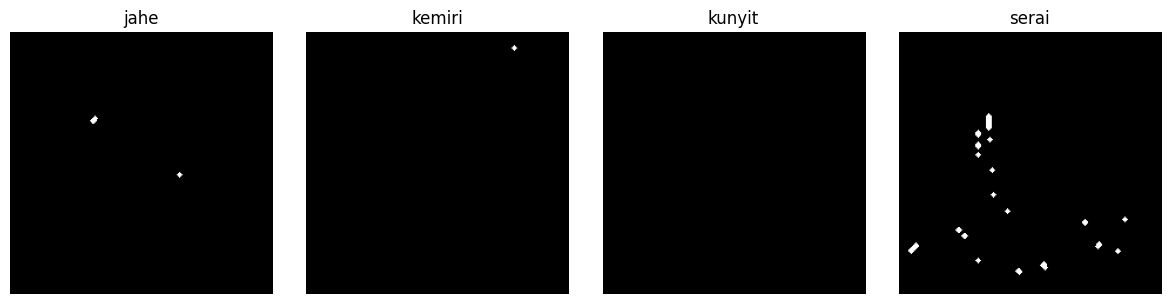

In [ ]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    idx = np.where(
        labels == kelas
    )[0][0]

    img = prepro3(
        data[idx], 
    )

    plt.subplot(
        1,
        4,
        i + 1
    )

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [ ]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(data)):
    D0   = glcm(data[i], 0)
    D45  = glcm(data[i], 45)
    D90  = glcm(data[i], 90)
    D135 = glcm(data[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(data)}")

   Progress: 100/840
   Progress: 200/840
   Progress: 300/840
   Progress: 400/840
   Progress: 500/840
   Progress: 600/840
   Progress: 700/840
   Progress: 800/840


In [ ]:
Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(data)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [ ]:

# Buat dictionary semua fitur
dataTable = {
    'Filename' : file_name,
    'Label'    : labels,
    # GLCM Features
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
print(f"   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan3.csv'")
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan3.csv'
   Shape DataFrame: (840, 30)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,jahe_1.jpg,jahe,46.554922,89.782564,54.931060,93.773968,0.392631,0.271465,0.329488,0.270699,...,0.000455,0.000341,0.023651,0.018525,0.021322,0.018465,0.994192,0.988790,0.993138,0.988291
1,jahe_10.JPG,jahe,84.622903,151.809958,128.279534,171.013164,0.563951,0.520018,0.533081,0.515770,...,0.178349,0.173943,0.428282,0.417857,0.422313,0.417065,0.971143,0.948359,0.956310,0.941826
2,jahe_100.jpg,jahe,18.938777,37.923179,19.992784,36.840915,0.642701,0.532900,0.605164,0.535536,...,0.058726,0.056064,0.242634,0.236653,0.242335,0.236779,0.996096,0.992180,0.995878,0.992403
3,jahe_101.jpg,jahe,114.991194,255.353886,144.379891,258.426928,0.500681,0.368097,0.419382,0.362660,...,0.001334,0.001215,0.039394,0.035027,0.036529,0.034853,0.988079,0.973479,0.985013,0.973160
4,jahe_102.jpg,jahe,37.520034,219.579673,190.365542,224.386255,0.513482,0.442283,0.490638,0.434809,...,0.030014,0.026582,0.178128,0.163008,0.173245,0.163041,0.993280,0.960045,0.965362,0.959170


In [ ]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 11
Fitur yang dipilih    : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


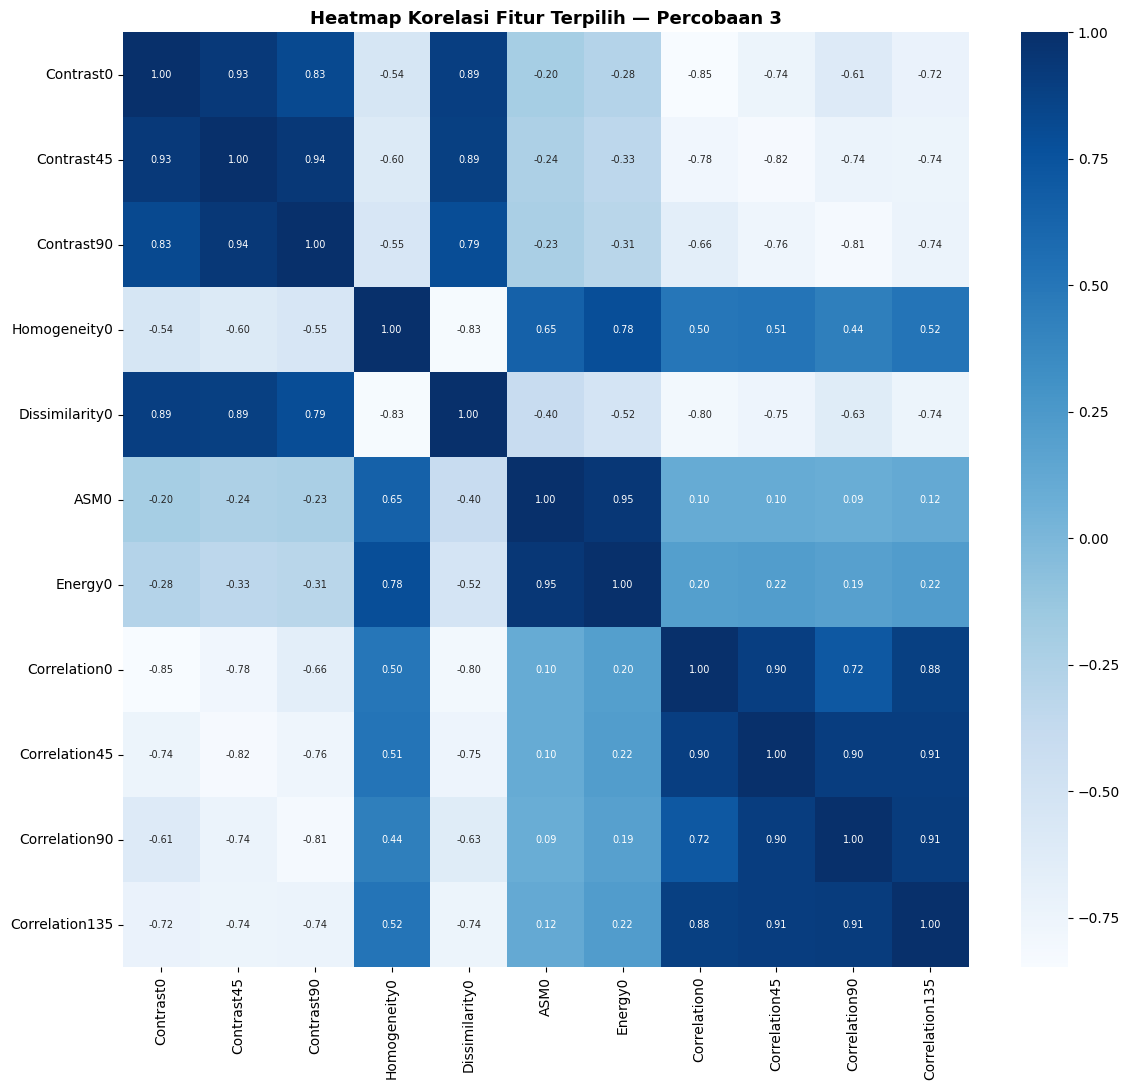

In [ ]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

train_mean = X_train.mean()
train_std  = X_train.std()

# Hindari pembagian dengan nol
train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print("Normalisasi Z-Score selesai!")
print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

Normalisasi Z-Score selesai!
   X_train setelah normalisasi: mean ≈ 0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ -0.0338


In [ ]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

print("Model berhasil didefinisikan!")
print("   - Random Forest  : n_estimators=100")
print("   - SVM            : kernel=RBF, C=1.0")
print("   - KNN            : n_neighbors=5")

Model berhasil didefinisikan!
   - Random Forest  : n_estimators=100
   - SVM            : kernel=RBF, C=1.0
   - KNN            : n_neighbors=5


In [ ]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

        jahe       1.00      1.00      1.00       168
      kemiri       1.00      1.00      1.00       168
      kunyit       1.00      1.00      1.00       168
       serai       1.00      1.00      1.00       168

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

        jahe       0.53      0.50      0.51        42
      kemiri       0.62      0.67      0.64        42
      kunyit       0.59      0.64      0.61        42
       serai       0.73      0.64      0.68        42

    accuracy                           0.61       168
   macro avg    

Berdasarkan hasil pengujian, metode Random Forest memperoleh F1-score sebesar 0,6133 dan menjadi metode dengan performa terbaik dibandingkan KNN dan SVM pada penelitian ini. Hasil tersebut menunjukkan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, dan klasifikasi menggunakan Random Forest mampu mengenali pola tekstur pada citra rempah dengan cukup baik. Meskipun demikian, peningkatan F1-score belum mencapai yang diharapkan. Hal ini dapat disebabkan oleh karakteristik data yang memiliki variasi tekstur, pencahayaan, serta kemiripan visual antar beberapa jenis rempah sehingga proses klasifikasi menjadi lebih menantang. Selain itu, pembagian data latih dan data uji juga dapat memengaruhi kemampuan model dalam melakukan generalisasi terhadap data yang belum pernah dilihat sebelumnya. Namun secara keseluruhan, hasil yang diperoleh menunjukkan bahwa metode Random Forest mampu memberikan performa yang baik dalam proses klasifikasi jenis rempah berdasarkan fitur tekstur yang diekstraksi menggunakan GLCM

In [ ]:
print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

        jahe       0.57      0.31      0.40        42
      kemiri       0.44      0.57      0.49        42
      kunyit       0.44      0.64      0.52        42
       serai       0.75      0.50      0.60        42

    accuracy                           0.51       168
   macro avg       0.55      0.51      0.50       168
weighted avg       0.55      0.51      0.50       168

  Accuracy  : 0.5060
  Precision : 0.5468
  Recall    : 0.5060
  F1-Score  : 0.5035


Berdasarkan hasil pengujian, metode Support Vector Machine (SVM) memperoleh F1-score sebesar 0,5035 dalam mengklasifikasikan jenis rempah berdasarkan fitur tekstur hasil ekstraksi GLCM. Hasil tersebut menunjukkan bahwa SVM mampu membentuk batas pemisah antar kelas dan mengenali pola yang terdapat pada data fitur yang digunakan. Meskipun nilai F1-score yang diperoleh masih belum mencapai yang diharapkan, hasil ini menunjukkan bahwa kombinasi fitur GLCM dan metode SVM tetap mampu melakukan proses klasifikasi dengan cukup baik. Nilai F1-score yang belum meningkat secara signifikan dapat dipengaruhi oleh karakteristik data yang memiliki tingkat kemiripan tekstur antar beberapa jenis rempah, sehingga proses pemisahan kelas menjadi lebih kompleks. Selain itu, performa SVM juga dipengaruhi oleh distribusi data dan parameter yang digunakan dalam pembentukan model. Namun secara keseluruhan, hasil yang diperoleh menunjukkan bahwa SVM mampu memanfaatkan fitur tekstur hasil ekstraksi GLCM untuk melakukan klasifikasi jenis rempah dan memberikan performa yang cukup baik.

In [ ]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")



 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

        jahe       0.64      0.70      0.67       168
      kemiri       0.60      0.72      0.65       168
      kunyit       0.66      0.61      0.63       168
       serai       0.87      0.66      0.75       168

    accuracy                           0.67       672
   macro avg       0.69      0.67      0.68       672
weighted avg       0.69      0.67      0.68       672

  Accuracy  : 0.6741
  Precision : 0.6910
  Recall    : 0.6741
  F1-Score  : 0.6768


In [ ]:
print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

        jahe       0.46      0.40      0.43        42
      kemiri       0.41      0.57      0.48        42
      kunyit       0.62      0.67      0.64        42
       serai       0.68      0.45      0.54        42

    accuracy                           0.52       168
   macro avg       0.54      0.52      0.52       168
weighted avg       0.54      0.52      0.52       168

  Accuracy  : 0.5238
  Precision : 0.5435
  Recall    : 0.5238
  F1-Score  : 0.5242


Berdasarkan hasil pengujian, metode K-Nearest Neighbor (KNN) memperoleh F1-score sebesar 0,5242 dalam mengklasifikasikan jenis rempah berdasarkan fitur tekstur hasil ekstraksi GLCM. Hasil tersebut menunjukkan bahwa KNN mampu mengenali pola kemiripan antar data dan melakukan klasifikasi dengan cukup baik berdasarkan kedekatan fitur pada ruang data. Meskipun demikian, nilai F1-score yang diperoleh masih belum mencapai yang diharapkan. Hal ini dapat dipengaruhi oleh karakteristik data yang memiliki variasi tekstur dan kemiripan visual antar beberapa jenis rempah, sehingga jarak antar kelas menjadi relatif berdekatan dan proses penentuan tetangga terdekat menjadi lebih menantang. Selain itu, performa KNN juga dipengaruhi oleh distribusi data latih yang digunakan, karena algoritma ini sangat bergantung pada kemiripan data yang tersedia untuk melakukan prediksi. Namun secara keseluruhan, hasil yang diperoleh menunjukkan bahwa metode KNN mampu memanfaatkan fitur tekstur GLCM untuk melakukan klasifikasi jenis rempah dengan tingkat performa yang cukup baik

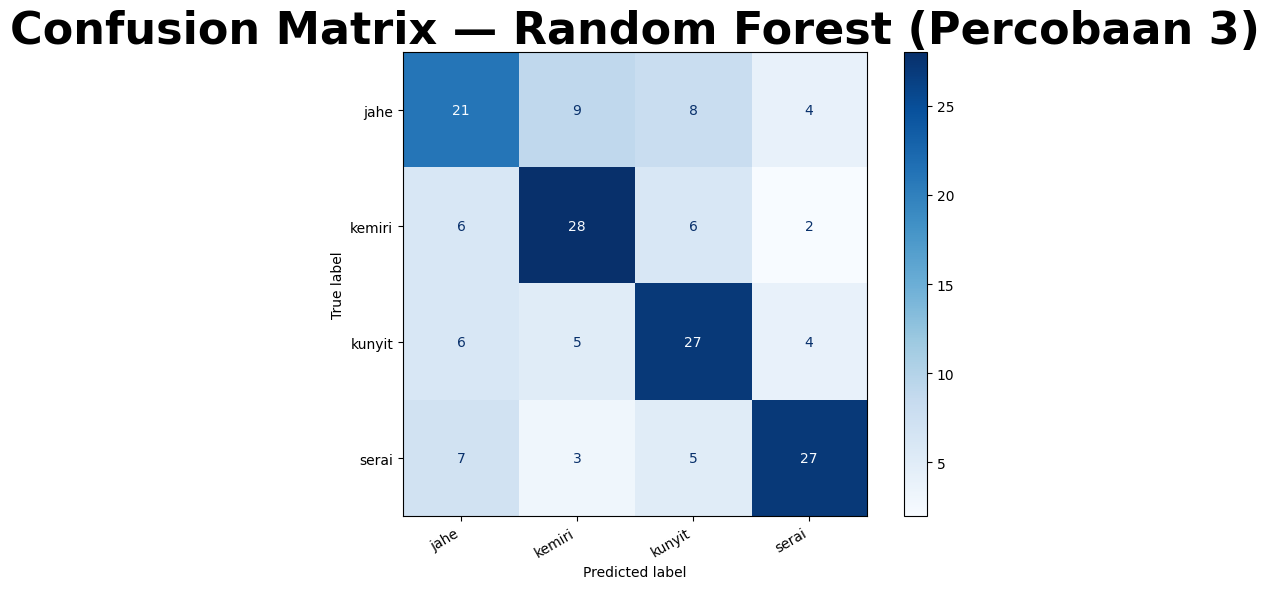

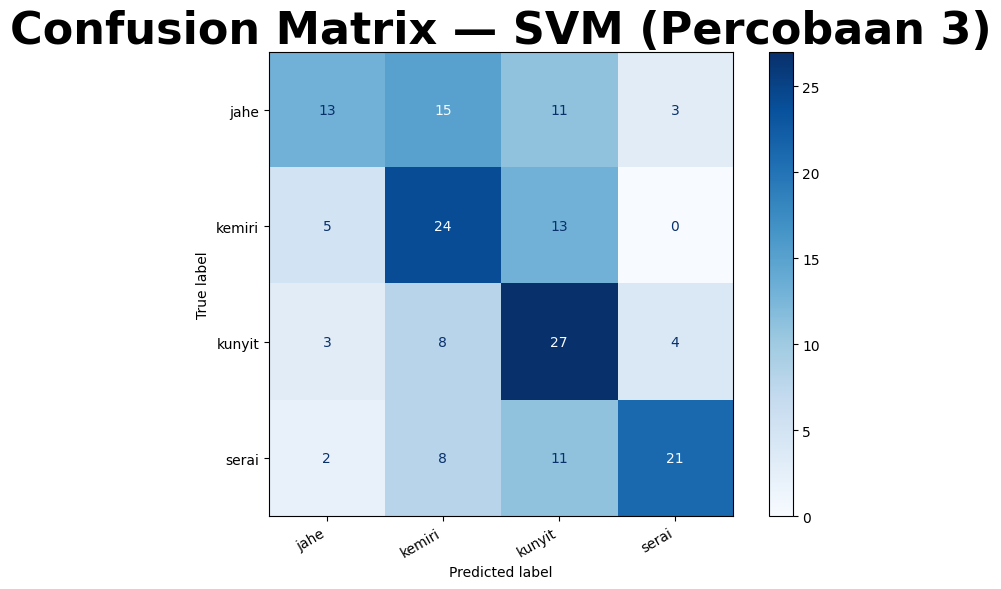

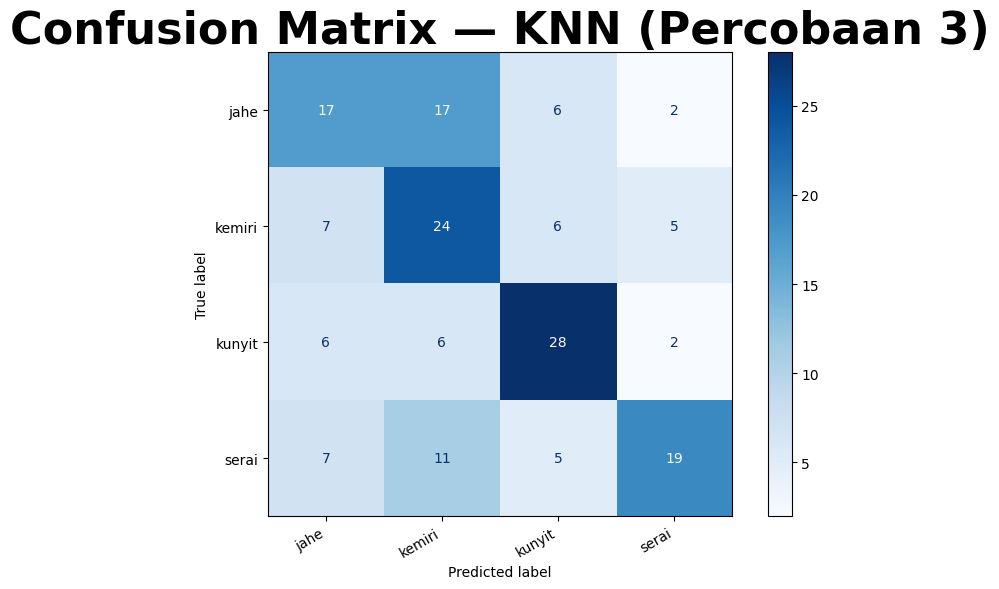

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=32, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 3)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 3)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 3)")